In [2]:
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
con = sqlite3.connect('../data/games.db')
games_df = pd.read_sql_query(
    "SELECT team1_player1, team1_player2, team1_score, team2_player1, team2_player2, team2_score "
    "FROM games WHERE status = 'finished'",
    con
)
con.close()
games_df.head()

,team1_player1,team1_player2,team1_score,team2_player1,team2_player2,team2_score
0,habby,ravi,21,nithin,akhil_shrikanth,18
1,suandi,harry,9,andy,sachee,21
2,yaw,ulf,13,pritto,luyi,21
3,sumit,annie,18,adam,sandeep_g.,21
4,rahul,harry,13,suandi,ravi,21


## Team Pair Win Rate Heatmap

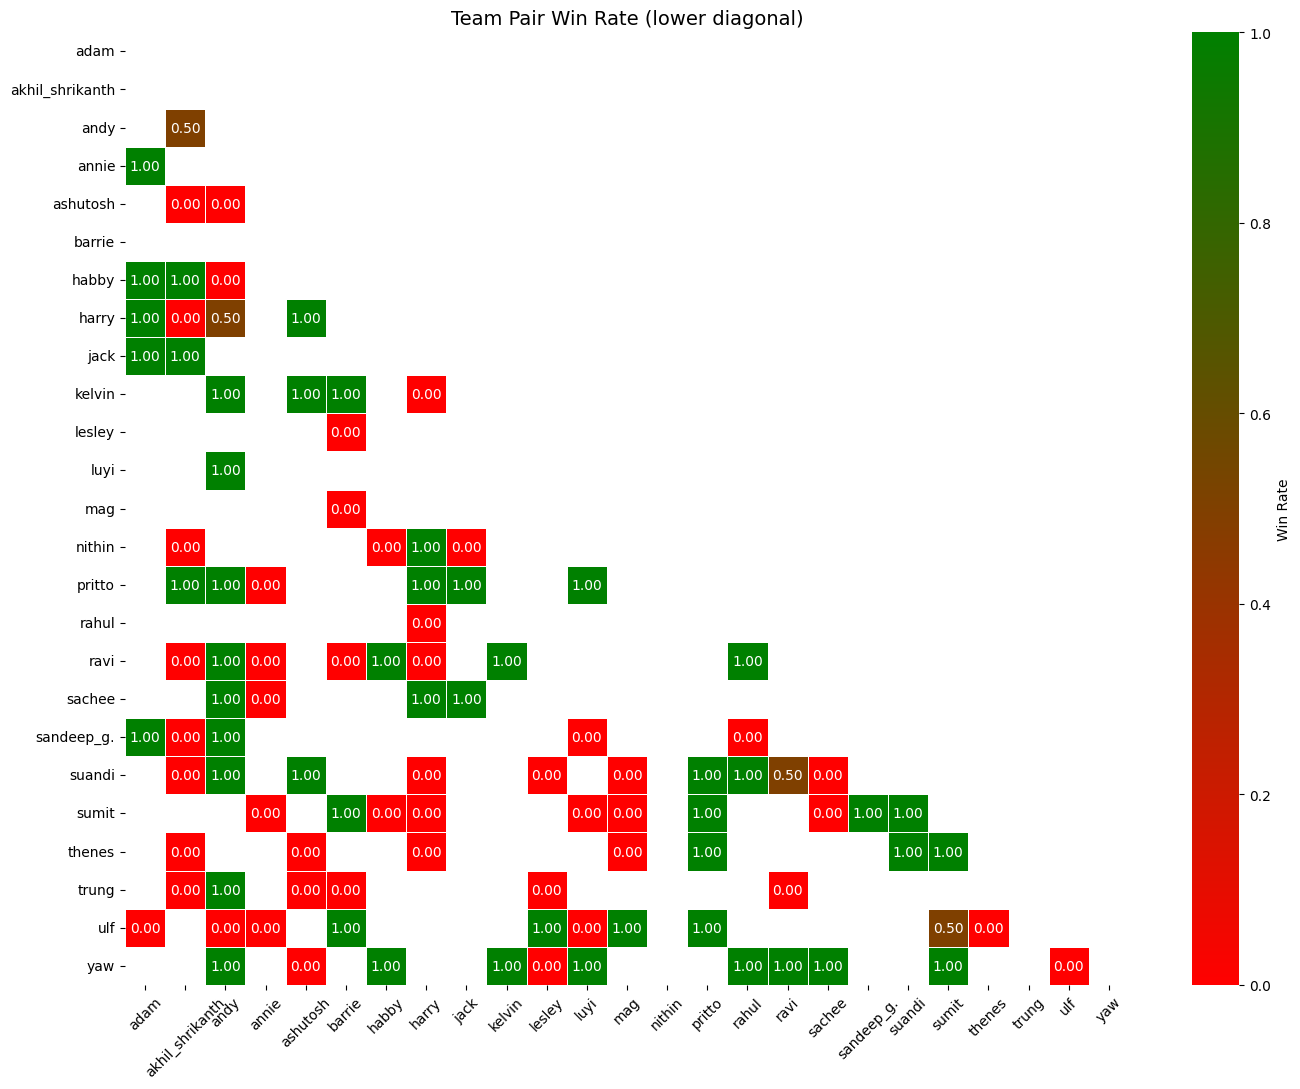

In [4]:
from matplotlib.colors import LinearSegmentedColormap
rg_cmap = LinearSegmentedColormap.from_list('rg', ['red', 'green'])

players = sorted(set(
    games_df['team1_player1'].tolist() + games_df['team1_player2'].tolist() +
    games_df['team2_player1'].tolist() + games_df['team2_player2'].tolist()
))
n = len(players)
idx = {p: i for i, p in enumerate(players)}

wins  = np.zeros((n, n))
games = np.zeros((n, n))

for _, row in games_df.iterrows():
    t1_won = row['team1_score'] > row['team2_score']
    for (p1, p2), won in [
        ((row['team1_player1'], row['team1_player2']), t1_won),
        ((row['team2_player1'], row['team2_player2']), not t1_won),
    ]:
        i, j = idx[p1], idx[p2]
        games[i, j] += 1
        games[j, i] += 1
        if won:
            wins[i, j] += 1
            wins[j, i] += 1

with np.errstate(invalid='ignore'):
    win_rate = np.where(games > 0, wins / games, np.nan)

# Lower-diagonal mask: show only cells where i > j (below the diagonal)
mask = np.ones((n, n), dtype=bool)
for i in range(n):
    for j in range(i):
        if not np.isnan(win_rate[i, j]):
            mask[i, j] = False

win_rate_df = pd.DataFrame(win_rate, index=players, columns=players)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    win_rate_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap=rg_cmap,
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Win Rate'},
)
ax.set_title('Team Pair Win Rate (lower diagonal)', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## Partnership Graph

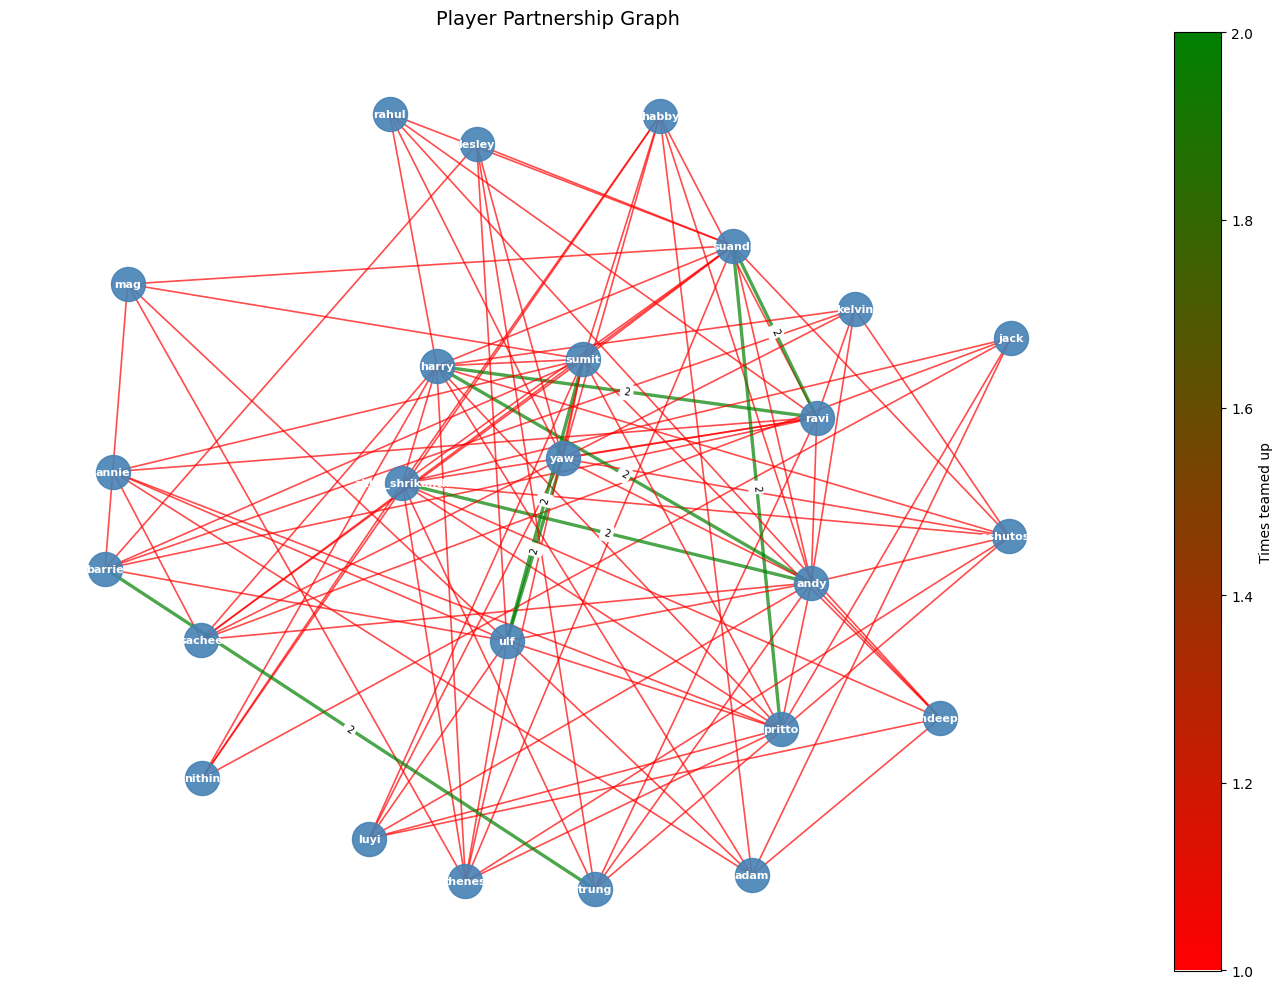

In [5]:
from matplotlib.colors import LinearSegmentedColormap
rg_cmap = LinearSegmentedColormap.from_list('rg', ['red', 'green'])

import networkx as nx

G = nx.Graph()

for _, row in games_df.iterrows():
    for p1, p2 in [
        (row['team1_player1'], row['team1_player2']),
        (row['team2_player1'], row['team2_player2']),
    ]:
        if G.has_edge(p1, p2):
            G[p1][p2]['weight'] += 1
        else:
            G.add_edge(p1, p2, weight=1)

pos = nx.spring_layout(G, seed=42, k=2.5)
weights = [G[u][v]['weight'] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='steelblue', alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    G, pos,
    width=[w * 1.2 for w in weights],
    edge_color=weights,
    edge_cmap=rg_cmap,
    alpha=0.7,
    ax=ax,
)
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 1}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)
sm = plt.cm.ScalarMappable(cmap=rg_cmap, norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
plt.colorbar(sm, ax=ax, label='Times teamed up')
ax.set_title('Player Partnership Graph', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Court Time per Player

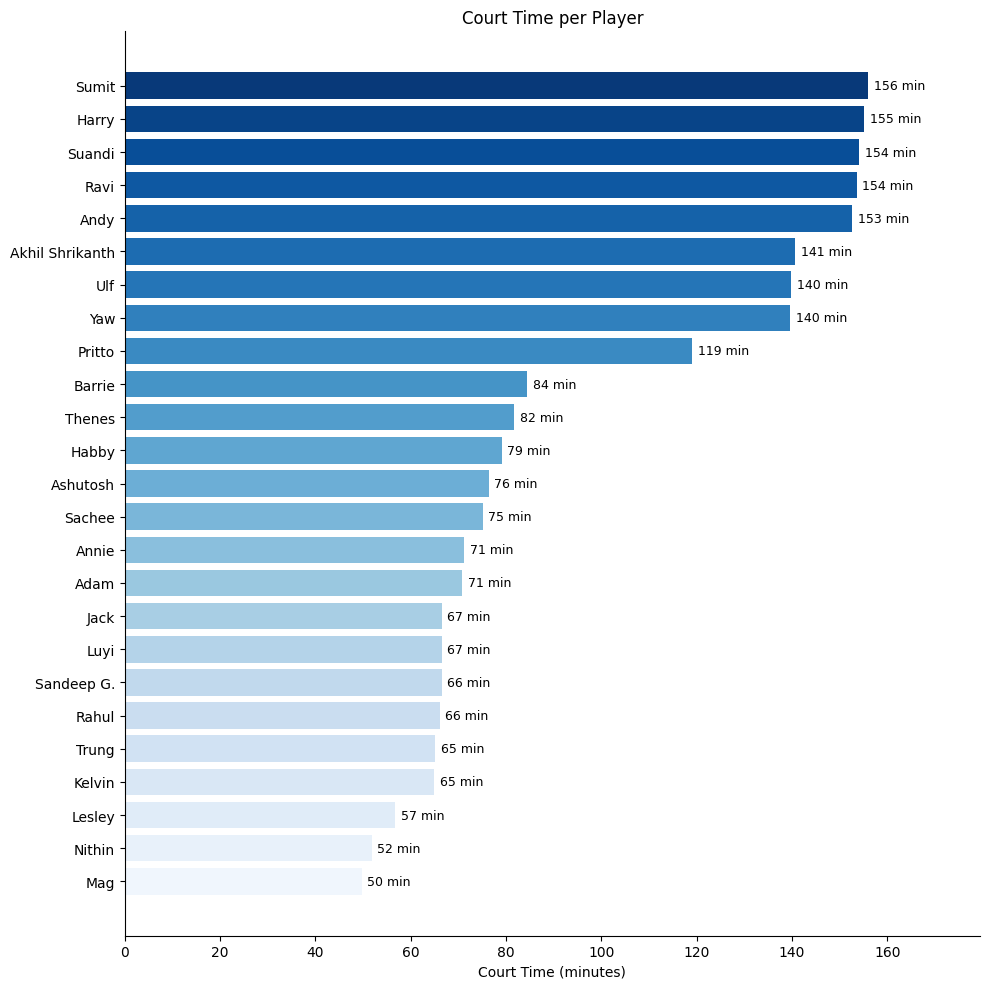

In [ ]:
con = sqlite3.connect('../data/games.db')
court_time_df = pd.read_sql_query(
    """
    SELECT p.player_name, SUM(duration_min) AS court_time_min
    FROM (
        SELECT team1_player1 AS player_id,
               (julianday(end_time) - julianday(start_time)) * 1440 AS duration_min
        FROM games WHERE status IN ('finished', 'abandoned')
          AND start_time IS NOT NULL AND end_time IS NOT NULL
        UNION ALL
        SELECT team1_player2,
               (julianday(end_time) - julianday(start_time)) * 1440
        FROM games WHERE status IN ('finished', 'abandoned')
          AND start_time IS NOT NULL AND end_time IS NOT NULL
        UNION ALL
        SELECT team2_player1,
               (julianday(end_time) - julianday(start_time)) * 1440
        FROM games WHERE status IN ('finished', 'abandoned')
          AND start_time IS NOT NULL AND end_time IS NOT NULL
        UNION ALL
        SELECT team2_player2,
               (julianday(end_time) - julianday(start_time)) * 1440
        FROM games WHERE status IN ('finished', 'abandoned')
          AND start_time IS NOT NULL AND end_time IS NOT NULL
    ) AS player_times
    JOIN players p USING (player_id)
    GROUP BY player_id
    ORDER BY court_time_min DESC
    """,
    con,
)
con.close()

fig, ax = plt.subplots(figsize=(10, max(5, len(court_time_df) * 0.4)))
bars = ax.barh(
    court_time_df['player_name'],
    court_time_df['court_time_min'],
    color=sns.color_palette('Blues_r', len(court_time_df)),
)
ax.bar_label(bars, fmt='%.0f min', padding=4, fontsize=9)
ax.set_xlabel('Court Time (minutes)')
ax.set_title('Court Time per Player')
ax.invert_yaxis()
ax.set_xlim(0, court_time_df['court_time_min'].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()